<h2>Modelling: Future Price Direction 1 (Logistic Regression)

The ML aspects of this project will be divided into two separate parts: 
- Predicting future price direction and,
- Predicting future price volatilty

It's very dificult predicting exact future price but if future direction and volatility can be predicted, an agent can take this information and size a position accordingly.

I want to create a model which takes in a sequence of prices and outputs a probability of the next price being higher or lower than the last (or the average) of the sequence.

One concern I have is if the day to day prices are too noisy that the next predicted value may not be particularly accurate i.e. it may also be noise. The model may have a low conviction in a decisive price movement. This could be overcome potentially by having the model take in some data and then say which the direction the price may be 1 week / 1 month from now, with an associated probability. This combined with a predicted volatility (to be modelled separately) may contain better information.

Furthermore, just price quotes may not be enough. It may be necessary to add price indicators such as RSI, MACD, and moving averages.

In [1]:
import sys
from pathlib import Path

PROJ_ROOT = Path().resolve().parents[0]
project_root = str(PROJ_ROOT)
sys.path.insert(0, project_root)

In [2]:
DATA_DIR = PROJ_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
RAW_DATA_PATH = RAW_DATA_DIR / "btcusd_data.pkl"
print(RAW_DATA_PATH)

/Users/cameroncochrane/Data Projects/vlXsnPPgKKnWqEJB/data/raw/btcusd_data.pkl


In [3]:
import pickle
import numpy as np
import pandas as pd

<h3> Logistic Regression

In [4]:
# Only load pickle files from a trusted source; unpickling can execute code.
with RAW_DATA_PATH.open("rb") as file:
    raw_data = pickle.load(file)

raw_data.head()

Price,Date,Close,High,Low,Open,Volume
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100


We will take 'Close' as the current price. From here, we need to create columns that offset the Close value to a given interval in the future e.g. 1 day, 5 day, 10 day, then return a binary value saying if it is higher (1) or lower (0) than the Close of the current day.

*<h4>1-day Data</h4>*

<h4>Feature Creation</h4>

Add column that contains a binary value which says whether the price 1-day into the future is larger or smaller than the current price (direction)

In [5]:
raw_data["Close_1"] = raw_data["Close"].shift(-1)
raw_data.head()

Price,Date,Close,High,Low,Open,Volume,Close_1
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,424.440002
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,394.795990
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,408.903992
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,398.821014
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,402.152008


In [6]:
raw_data["Direction_1"] = np.where(raw_data["Close_1"] > raw_data["Close"], 1, 0)
raw_data.head()

Price,Date,Close,High,Low,Open,Volume,Close_1,Direction_1
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,424.440002,0
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,394.795990,0
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,408.903992,1
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,398.821014,0
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,402.152008,1


Function to carry this out arbitrarily:

In [7]:
def add_direction(data: pd.DataFrame, shift: int = 1, price: str = "Close") -> pd.DataFrame:
    """Add an integer label: 1 if the future price is higher, otherwise 0.

    Rows without a future price are left as missing. Example:
    `data = add_direction(raw_data, shift=5)`.
    """
    if shift < 1:
        raise ValueError("shift must be a positive integer")

    result = data.copy()
    future_price = result[price].shift(-shift)
    result[f"Direction_{shift}"] = (
        (future_price > result[price]).astype("Int64").where(future_price.notna())
    )
    return result

In [8]:
# Then drop Close_1, Date (no useful information):
raw_data = raw_data.drop(columns=["Close_1", "Date"])
raw_data.head()

Price,Close,High,Low,Open,Volume,Direction_1
0,457.334015,468.174011,452.421997,465.864014,21056800,0
1,424.440002,456.859985,413.104004,456.859985,34483200,0
2,394.795990,427.834991,384.532013,424.102997,37919700,1
3,408.903992,423.295990,389.882996,394.673004,36863600,0
4,398.821014,412.425995,393.181000,408.084991,26580100,1


<h5>Additional Information: Price Indicators:

Lot's of technical trading relies on indicators other than the price. They include:
- Relative Strength Index (RSI)
- Moving Average Convergence-Divergence (MACD)
- Moving Averages
- Intraday Range (IDR)
- Average True Range (ATR)

*RSI:*

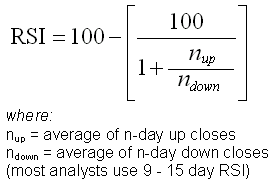

*MACD:*

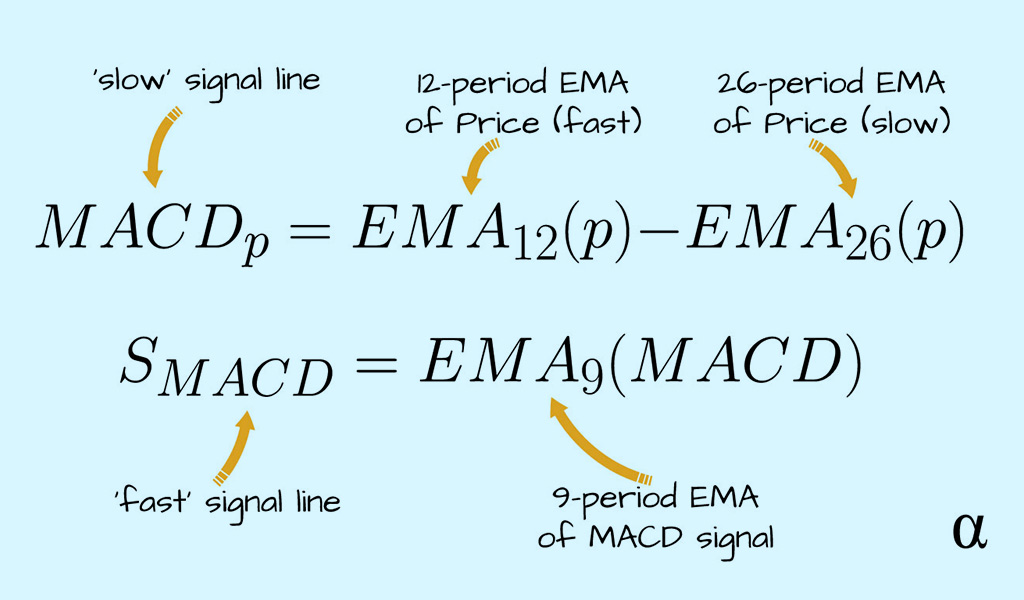

The difference between slow and fast MACD signal lines gives the histogram commonly seen on trading charts. It can help spot price reversals.
(This is the 3rd part of the calculation, but it doesn't necessarily contain new info as it is the difference between two values already quoted. May be useful when feature selection is required...)

*Moving Averages:*
- Simple (SMA):
    - Sum of close/current prices divided by the number of observations where each observation contributes an equal weight
- Exponential (EMA):
    - Similar to SMA except a greater weighting is applied to the most recent observations.

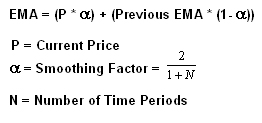

*IDR and ATR:*

- IDR is simply High - Low.
- ATR is a smoothed average of IDR over a set period.

The key thing to watch out for is for the propensity (if present) of any of these indicators to leak data. They all use backward facing data so this shouldn'r be an issue.

A function(s) to add these indicators as features to each observation:

In [9]:
def add_SMA(data: pd.DataFrame, n: int = 7, price: str = "Close") -> pd.DataFrame:
    """Add an n-period simple moving average.

    Example: `data = add_SMA(raw_data, n=7)`
    """
    result = data.copy()
    result[f"SMA_{n}"] = result[price].rolling(window=n, min_periods=n).mean() #1
    return result


def add_EMA(data: pd.DataFrame, n: int = 7, price: str = "Close") -> pd.DataFrame:
    """Add an n-period exponential moving average.

    Example: `data = add_EMA(raw_data, n=7)`
    """
    result = data.copy()
    result[f"EMA_{n}"] = result[price].ewm(span=n, min_periods=n, adjust=False).mean() #1
    return result


def add_ranges(data: pd.DataFrame, n: int = 4, low: str = "Low", high: str = "High") -> pd.DataFrame:
    """Add intraday range (IDR) and n-period average true range (ATR).

    Example: `data = add_ranges(raw_data, n=4)`
    """
    result = data.copy()
    previous_close = result["Close"].shift(1)
    result["IDR"] = result[high] - result[low] #1
    true_range = pd.concat(
        [
            result[high] - result[low],
            (result[high] - previous_close).abs(),
            (result[low] - previous_close).abs(),
        ],
        axis=1,
    ).max(axis=1)
    result[f"ATR_{n}"] = true_range.rolling(window=n, min_periods=n).mean() #1
    return result


def add_RSI(data: pd.DataFrame, n: int = 14) -> pd.DataFrame:
    """Add an n-period RSI calculated with Wilder-style exponential averages.

    Example: `data = add_RSI(raw_data, n=14)`
    """
    result = data.copy()
    change = result["Close"].diff()
    average_gain = change.clip(lower=0).ewm(alpha=1 / n, min_periods=n, adjust=False).mean()
    average_loss = -change.clip(upper=0).ewm(alpha=1 / n, min_periods=n, adjust=False).mean()

    rsi = 100 - 100 / (1 + average_gain / average_loss)
    rsi = rsi.mask((average_loss == 0) & (average_gain > 0), 100)
    rsi = rsi.mask((average_loss == 0) & (average_gain == 0), 50)
    result[f"RSI_{n}"] = rsi #1
    return result


def add_MACD(data: pd.DataFrame) -> pd.DataFrame:
    """Add MACD (12/26), its 9-period signal line, and the histogram.

    Example: `data = add_MACD(raw_data)`
    """
    result = data.copy()
    close = result["Close"]
    fast_ema = close.ewm(span=12, min_periods=12, adjust=False).mean()
    slow_ema = close.ewm(span=26, min_periods=26, adjust=False).mean()
    result["MACD"] = fast_ema - slow_ema #1
    result["MACD_signal"] = result["MACD"].ewm(span=9, min_periods=9, adjust=False).mean() #2
    result["MACD_hist"] = result["MACD"] - result["MACD_signal"] #3
    return result

In [10]:
data = add_SMA(data = raw_data)
data = add_EMA(data = data)
data = add_ranges(data = data)
data = add_RSI(data = data)
data = add_MACD(data = data)
data.head()

Price,Close,High,Low,Open,Volume,Direction_1,SMA_7,EMA_7,IDR,ATR_4,RSI_14,MACD,MACD_signal,MACD_hist
0,457.334015,468.174011,452.421997,465.864014,21056800,0,NaN,NaN,15.752014,NaN,NaN,NaN,NaN,NaN
1,424.440002,456.859985,413.104004,456.859985,34483200,0,NaN,NaN,43.755981,NaN,NaN,NaN,NaN,NaN
2,394.795990,427.834991,384.532013,424.102997,37919700,1,NaN,NaN,43.302979,NaN,NaN,NaN,NaN,NaN
3,408.903992,423.295990,389.882996,394.673004,36863600,0,NaN,NaN,33.412994,34.174500,NaN,NaN,NaN,NaN
4,398.821014,412.425995,393.181000,408.084991,26580100,1,NaN,NaN,19.244995,35.047745,NaN,NaN,NaN,NaN


In [11]:
data.tail()

Price,Close,High,Low,Open,Volume,Direction_1,SMA_7,EMA_7,IDR,ATR_4,RSI_14,MACD,MACD_signal,MACD_hist
4394,83502.609375,84972.664062,82570.718750,84454.117188,42589028679,1,84476.631696,83787.686186,2401.945312,1528.330078,60.920863,2309.066922,2235.023516,74.043406
4395,83622.429688,84511.281250,82739.093750,83500.320312,28029782264,0,84112.367188,83746.372061,1772.187500,1455.246094,61.255696,2192.398904,2226.498594,-34.099690
4396,83553.851562,85599.804688,82927.875000,83621.398438,36290317874,1,83993.916295,83698.241936,2671.929688,1962.710938,60.933899,2070.537114,2195.306298,-124.769184
4397,84853.101562,85224.273438,83132.757812,83554.250000,32802609098,1,84061.636161,83986.956843,2091.515625,2234.394531,64.715788,2055.109363,2167.266911,-112.157548
4398,86545.992188,86818.039062,84555.460938,84849.929688,40108093440,0,84420.360491,84626.715679,2262.578125,2199.552734,68.935596,2154.647450,2164.743019,-10.095569


Based on the time lag of some of the indicators there are a few NaN rows. These will have to be removed.

In [12]:
data = data.dropna().copy()
data.head()

Price,Close,High,Low,Open,Volume,Direction_1,SMA_7,EMA_7,IDR,ATR_4,RSI_14,MACD,MACD_signal,MACD_hist
33,382.845001,390.084015,378.252014,389.230988,16419000,1,389.398568,385.053349,11.832001,11.397491,36.470417,-3.112802,-7.666231,4.553430
34,386.475006,392.645996,380.834015,382.420990,14188900,0,387.342141,385.408763,11.811981,11.828239,38.000530,-2.514616,-6.635908,4.121292
35,383.157990,388.575989,382.248993,386.118011,11641300,0,385.682853,384.846070,6.326996,9.363243,37.120720,-2.281901,-5.765107,3.483206
36,358.416992,385.048004,356.446991,382.962006,26456900,0,382.234423,378.238800,28.601013,14.642998,31.299762,-4.047210,-5.421527,1.374317
37,358.345001,364.345001,353.304993,358.591003,15585700,0,378.603995,373.265351,11.040009,14.445000,31.284389,-5.389908,-5.415203,0.025295


In [13]:
data.shape

(4366, 14)

Save the Direction_1 data (containing the indicators) in a pkl file. From this it is easy to add other 'Direction_n' time frames.

In [14]:
PROCESSED_DATA_DIR = DATA_DIR / "processed"
DCN_DATA_DIR = PROCESSED_DATA_DIR / "direction"
PRE_SPLIT_DATA_DIR = DCN_DATA_DIR / "lr"

file_name = "ind_data.pkl"

PRE_SPLIT_DATA_LR_PATH = PRE_SPLIT_DATA_DIR / file_name # Pre split data containing indicators and 'Direction_1' label column

# Save:
PRE_SPLIT_DATA_DIR.mkdir(parents=True, exist_ok=True)
with PRE_SPLIT_DATA_LR_PATH.open("wb") as file:
    pickle.dump(data, file)

<h3>Data Splitting

In [15]:
data.head() #Direction_1 data

Price,Close,High,Low,Open,Volume,Direction_1,SMA_7,EMA_7,IDR,ATR_4,RSI_14,MACD,MACD_signal,MACD_hist
33,382.845001,390.084015,378.252014,389.230988,16419000,1,389.398568,385.053349,11.832001,11.397491,36.470417,-3.112802,-7.666231,4.553430
34,386.475006,392.645996,380.834015,382.420990,14188900,0,387.342141,385.408763,11.811981,11.828239,38.000530,-2.514616,-6.635908,4.121292
35,383.157990,388.575989,382.248993,386.118011,11641300,0,385.682853,384.846070,6.326996,9.363243,37.120720,-2.281901,-5.765107,3.483206
36,358.416992,385.048004,356.446991,382.962006,26456900,0,382.234423,378.238800,28.601013,14.642998,31.299762,-4.047210,-5.421527,1.374317
37,358.345001,364.345001,353.304993,358.591003,15585700,0,378.603995,373.265351,11.040009,14.445000,31.284389,-5.389908,-5.415203,0.025295


In [16]:
# Separate X and y (Direction_1):
X = data.drop(columns=["Direction_1"])
y = data["Direction_1"]

Looking at this now when we extend the Direction_1 column to a longer period e.g the price direction n = 5,7 10 days from now (Direction_n), we will be able to make these datasets from the indicator-rich dataset just made here as none of these indicators were made using information in the Direction_1 column...

<h4>EDA and Feature Selection</h4>

Some feature selection techniques to carry out involving data with numerical features and categorical labels:
- Box and violin plots

- Correlation analysis
    - Point-biserial correlation

- Mutual information

- Logistic regression w/ L1/lasso regression

Something important to note is the features may have differing correlation between different labels. Here we have Direction_1 as the label, where it looks at the price one day ahead, but longer timeframes such as 5, 7, or 10 days ahead (not created yet) may output different results during feature selection.

In [17]:
features = list(X.columns)
print(features)
# All features are numerical. Only the label is categorical.

['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_7', 'EMA_7', 'IDR', 'ATR_4', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist']


In [18]:
# Create a 'new' variable containing the EDA / feature selection dataset:
fs_data = X.copy()
fs_data['Direction_1'] = y
fs_data.head()

Price,Close,High,Low,Open,Volume,SMA_7,EMA_7,IDR,ATR_4,RSI_14,MACD,MACD_signal,MACD_hist,Direction_1
33,382.845001,390.084015,378.252014,389.230988,16419000,389.398568,385.053349,11.832001,11.397491,36.470417,-3.112802,-7.666231,4.553430,1
34,386.475006,392.645996,380.834015,382.420990,14188900,387.342141,385.408763,11.811981,11.828239,38.000530,-2.514616,-6.635908,4.121292,0
35,383.157990,388.575989,382.248993,386.118011,11641300,385.682853,384.846070,6.326996,9.363243,37.120720,-2.281901,-5.765107,3.483206,0
36,358.416992,385.048004,356.446991,382.962006,26456900,382.234423,378.238800,28.601013,14.642998,31.299762,-4.047210,-5.421527,1.374317,0
37,358.345001,364.345001,353.304993,358.591003,15585700,378.603995,373.265351,11.040009,14.445000,31.284389,-5.389908,-5.415203,0.025295,0


*Box and Violin Plots*

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

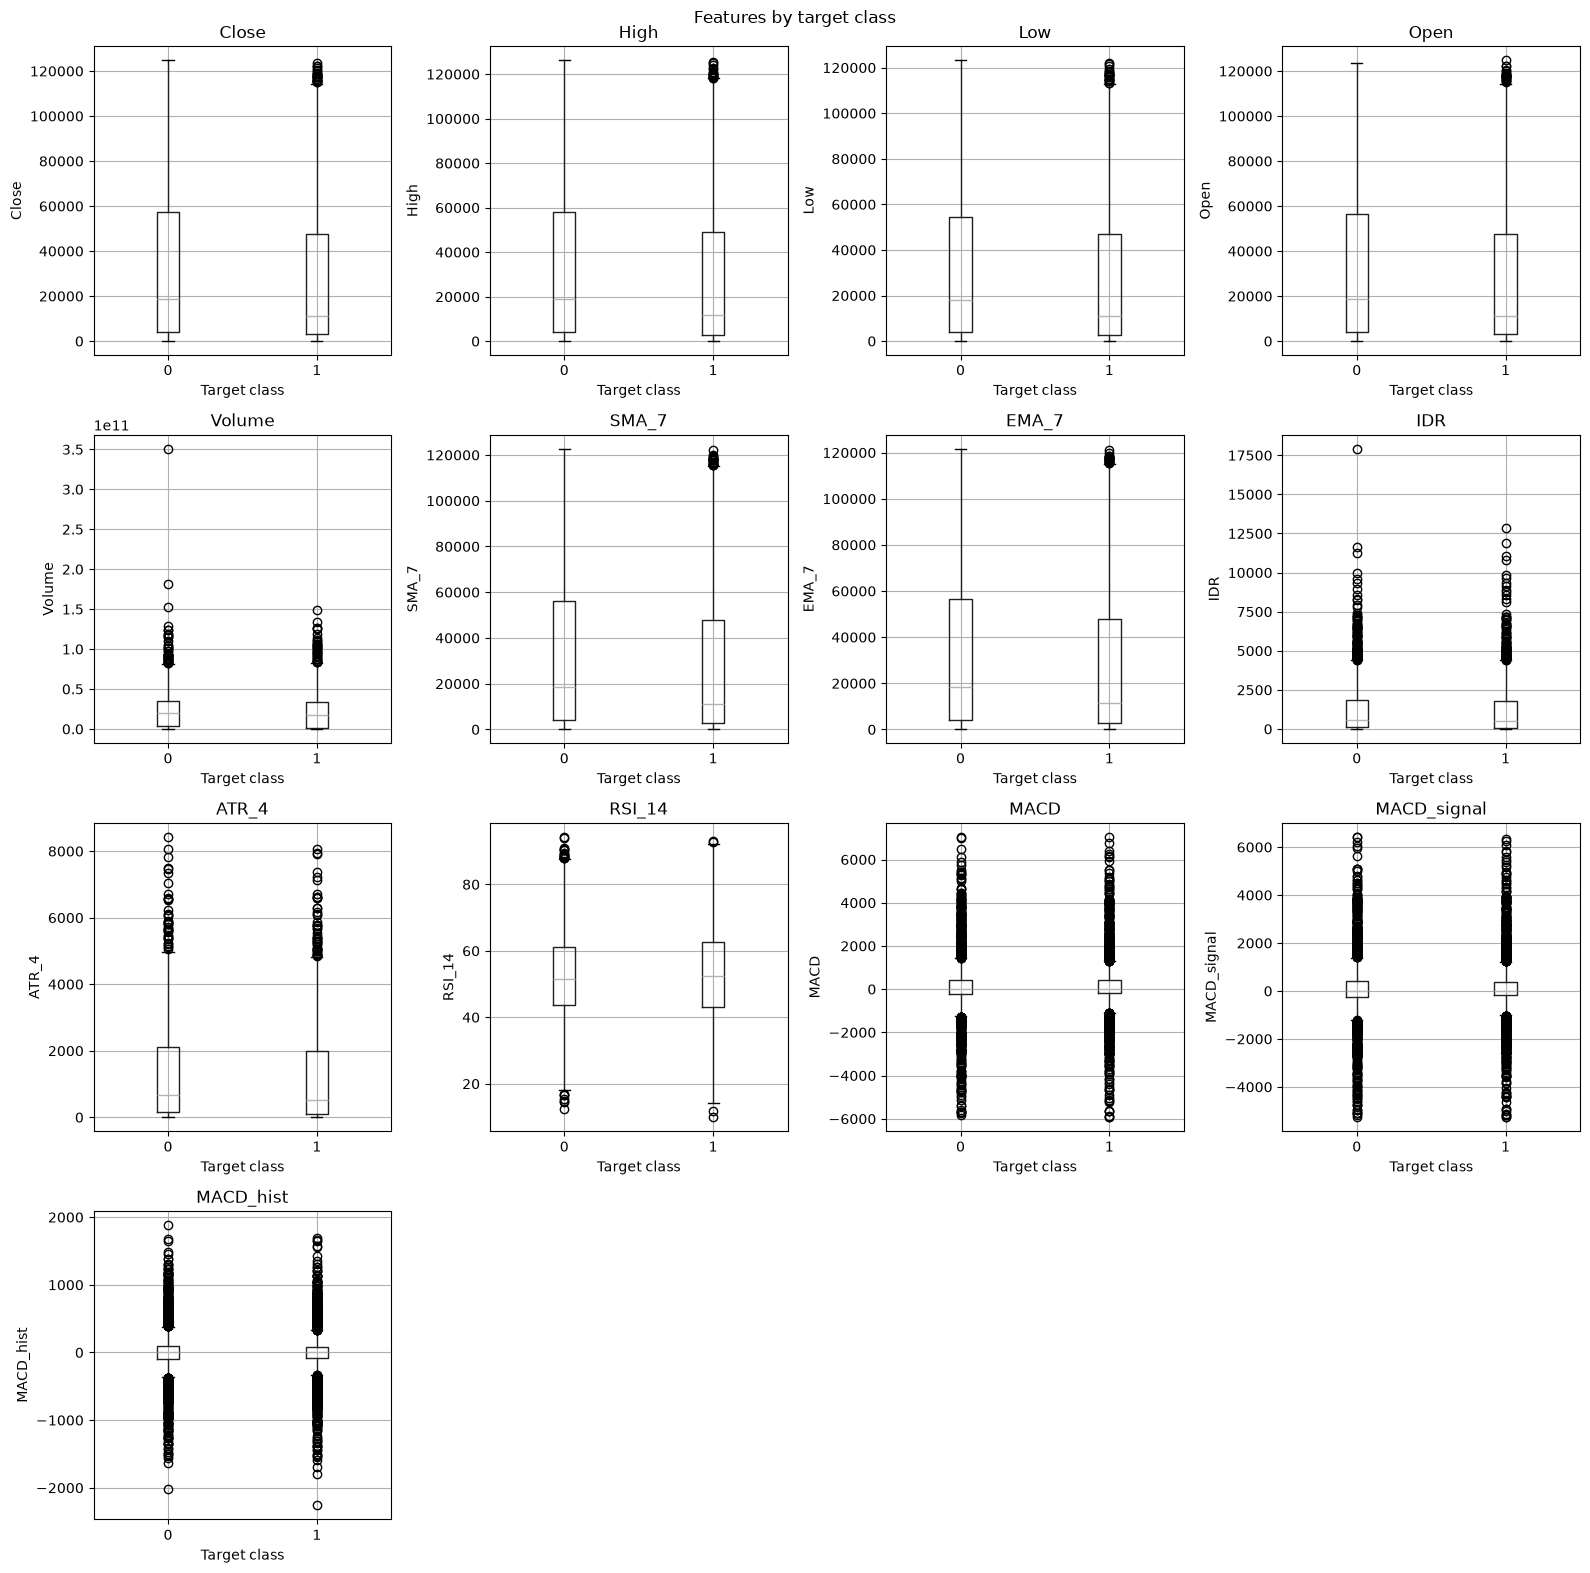

In [20]:
# Box plots:
ncols = 4
nrows = (len(features) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = np.asarray(axes).ravel()

for ax, feature in zip(axes, features):
    fs_data.boxplot(column=feature, by="Direction_1", ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("Target class")
    ax.set_ylabel(feature)

for ax in axes[len(features):]:
    ax.set_visible(False)

fig.suptitle("Features by target class")
fig.tight_layout()
plt.show()

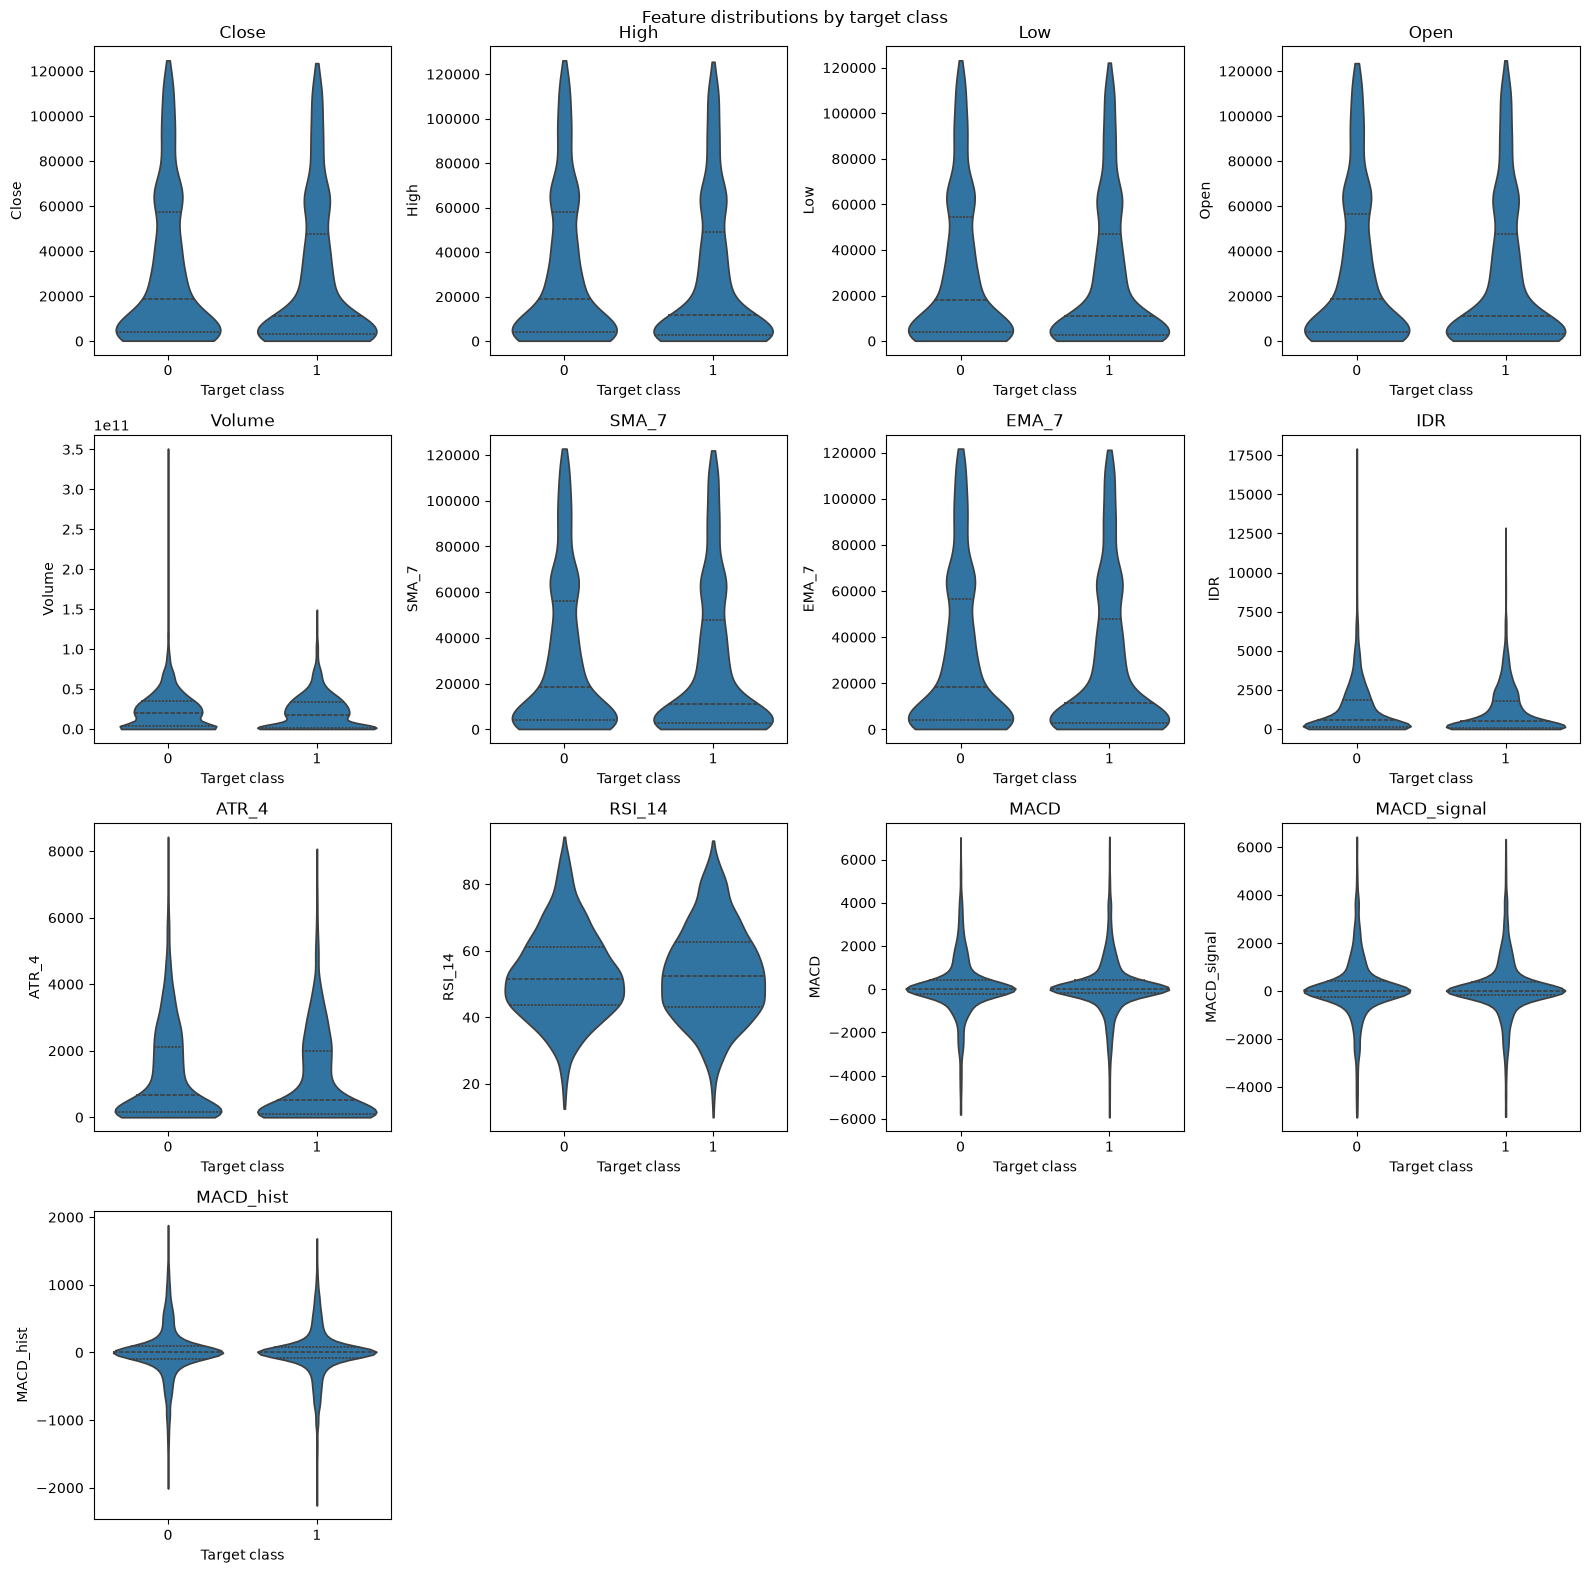

In [21]:
# Violin plots:
ncols = 4
nrows = (len(features) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = np.asarray(axes).ravel()

for ax, feature in zip(axes, features):
    sns.violinplot(data=fs_data, x="Direction_1", y=feature, ax=ax, inner="quartile", cut=0)
    ax.set_title(feature)
    ax.set_xlabel("Target class")
    ax.set_ylabel(feature)

for ax in axes[len(features):]:
    ax.set_visible(False)

fig.suptitle("Feature distributions by target class")
fig.tight_layout()
plt.show()

Very dificult to spot any variance in features between the two possible classes visually.

*Correlation: Eta Squared*

In [22]:
def eta_squared(categories: pd.Series, values: pd.Series) -> float:
    """Calculate eta-squared for a categorical target and numeric feature."""

    categories = pd.Series(categories)
    values = pd.Series(values)

    valid = categories.notna() & values.notna()
    categories = categories.loc[valid]
    values = values.loc[valid]

    if values.empty:
        return np.nan

    overall_mean = values.mean()

    ss_between = 0.0

    for category in categories.unique():
        group = values.loc[categories == category]

        ss_between += len(group) * (
            group.mean() - overall_mean
        ) ** 2

    ss_total = ((values - overall_mean) ** 2).sum()

    if ss_total == 0:
        return 0.0

    return ss_between / ss_total

eta_results_1 = pd.Series(
    {
        feature: eta_squared(
            fs_data['Direction_1'],
            fs_data[feature],
        )
        for feature in features
    },
    name="eta_squared",
).sort_values(ascending=False)

print(eta_results_1)

Close          0.002026
Low            0.001962
High           0.001956
EMA_7          0.001934
SMA_7          0.001914
Open           0.001910
Volume         0.001808
ATR_4          0.001378
IDR            0.000918
RSI_14         0.000470
MACD_hist      0.000189
MACD_signal    0.000041
MACD           0.000005
Name: eta_squared, dtype: float64


What if 'Direction_1' was changed to something like 'Direction_5' or 'Direction_7' (i.e. 5 and 7 days ahead, respectively)?

It's easy to implement Direction_5 / Direction_7 features from 'X' using the above 'add_direction()' function

In [23]:
X_y_5 = add_direction(X, 5, "Close")
X_y_7 = add_direction(X, 7, "Close")
X_y_14 = add_direction(X, 14, "Close")
X_y_20 = add_direction(X, 20, "Close")
X_y_5 = X_y_5.dropna()
X_y_7 = X_y_7.dropna()
X_y_14 = X_y_14.dropna()
X_y_20 = X_y_20.dropna()

In [24]:
eta_results_5 = pd.Series(
    {
        feature: eta_squared(
            X_y_5['Direction_5'],
            X_y_5[feature],
        )
        for feature in features
    },
    name="eta_squared",
).sort_values(ascending=False)

print(eta_results_5)

Close          3.582073e-03
Low            3.526836e-03
Open           3.494014e-03
High           3.486873e-03
EMA_7          3.480810e-03
SMA_7          3.460808e-03
ATR_4          1.840577e-03
IDR            1.257244e-03
Volume         8.820664e-04
RSI_14         8.047441e-04
MACD_hist      4.557894e-04
MACD_signal    3.185372e-05
MACD           3.051702e-07
Name: eta_squared, dtype: float64


In [25]:
eta_results_7 = pd.Series(
    {
        feature: eta_squared(
            X_y_7['Direction_7'],
            X_y_7[feature],
        )
        for feature in features
    },
    name="eta_squared",
).sort_values(ascending=False)

print(eta_results_7)

Close          0.003550
Low            0.003549
EMA_7          0.003531
SMA_7          0.003507
Open           0.003487
High           0.003476
RSI_14         0.002454
ATR_4          0.002157
Volume         0.001510
IDR            0.000875
MACD_signal    0.000536
MACD           0.000451
MACD_hist      0.000007
Name: eta_squared, dtype: float64


In [26]:
eta_results_14 = pd.Series(
    {
        feature: eta_squared(
            X_y_14['Direction_14'],
            X_y_14[feature],
        )
        for feature in features
    },
    name="eta_squared",
).sort_values(ascending=False)

print(eta_results_14)

ATR_4          0.009454
SMA_7          0.008506
EMA_7          0.008498
High           0.008415
Close          0.008374
Open           0.008350
Low            0.008254
IDR            0.007040
RSI_14         0.006709
Volume         0.005173
MACD           0.000790
MACD_signal    0.000648
MACD_hist      0.000199
Name: eta_squared, dtype: float64


In [27]:
eta_results_20 = pd.Series(
    {
        feature: eta_squared(
            X_y_20['Direction_20'],
            X_y_20[feature],
        )
        for feature in features
    },
    name="eta_squared",
).sort_values(ascending=False)

print(eta_results_20)

EMA_7          0.014201
SMA_7          0.014121
Close          0.014051
High           0.014029
Open           0.013926
Low            0.013899
ATR_4          0.012690
IDR            0.009295
Volume         0.007988
RSI_14         0.004883
MACD           0.002646
MACD_hist      0.002097
MACD_signal    0.001667
Name: eta_squared, dtype: float64


Longer timeframes looking ahead give a greater separability...

There may be instances where if volatility is above the long term average, the shorter term direction models (Direction_1, Direction_5) will give a more accurate prediction compared to the longer term models (Direction_7, Direction_20). Would it be better to train, tune, and utilise a selection of these models. If and where they are used will depend on volatility.

*Mutual Information*

In [28]:
from sklearn.feature_selection import mutual_info_classif

In [29]:
fs_data.head()

Price,Close,High,Low,Open,Volume,SMA_7,EMA_7,IDR,ATR_4,RSI_14,MACD,MACD_signal,MACD_hist,Direction_1
33,382.845001,390.084015,378.252014,389.230988,16419000,389.398568,385.053349,11.832001,11.397491,36.470417,-3.112802,-7.666231,4.553430,1
34,386.475006,392.645996,380.834015,382.420990,14188900,387.342141,385.408763,11.811981,11.828239,38.000530,-2.514616,-6.635908,4.121292,0
35,383.157990,388.575989,382.248993,386.118011,11641300,385.682853,384.846070,6.326996,9.363243,37.120720,-2.281901,-5.765107,3.483206,0
36,358.416992,385.048004,356.446991,382.962006,26456900,382.234423,378.238800,28.601013,14.642998,31.299762,-4.047210,-5.421527,1.374317,0
37,358.345001,364.345001,353.304993,358.591003,15585700,378.603995,373.265351,11.040009,14.445000,31.284389,-5.389908,-5.415203,0.025295,0


In [30]:
# Direction_1
X_1 = fs_data[features]
y_1 = fs_data['Direction_1']

mi_scores_1 = mutual_info_classif(
    X_1,
    y_1,
    discrete_features=False,
    random_state=42,
)

mi_results_1 = pd.Series(
    mi_scores_1,
    index=X_1.columns,
    name="mutual_information",
).sort_values(ascending=False)

print(mi_results_1)

Price
High           0.017674
Open           0.017123
Volume         0.016770
SMA_7          0.013333
RSI_14         0.009298
ATR_4          0.007715
MACD_hist      0.005255
MACD           0.001166
Close          0.000000
Low            0.000000
EMA_7          0.000000
IDR            0.000000
MACD_signal    0.000000
Name: mutual_information, dtype: float64


In [31]:
# Direction_5
mi_scores_5 = mutual_info_classif(
    X_y_5[features],
    X_y_5['Direction_5'],
    discrete_features=False,
    random_state=42,
)

mi_results_5 = pd.Series(
    mi_scores_5,
    index=X_y_5[features].columns,
    name="mutual_information",
).sort_values(ascending=False)

print(mi_results_5)

Price
EMA_7          0.049502
High           0.046309
Low            0.045453
SMA_7          0.032852
Open           0.031371
Close          0.029690
Volume         0.024581
MACD_signal    0.020384
MACD_hist      0.014465
ATR_4          0.010187
RSI_14         0.004959
IDR            0.002407
MACD           0.001550
Name: mutual_information, dtype: float64


In [32]:
# Direction_7
mi_scores_7 = mutual_info_classif(
    X_y_7[features],
    X_y_7['Direction_7'],
    discrete_features=False,
    random_state=42,
)

mi_results_7 = pd.Series(
    mi_scores_7,
    index=X_y_7[features].columns,
    name="mutual_information",
).sort_values(ascending=False)

print(mi_results_7)

Price
Low            0.063088
Close          0.058535
EMA_7          0.058455
High           0.058321
Open           0.047459
SMA_7          0.045982
Volume         0.029485
MACD_hist      0.016457
ATR_4          0.013099
RSI_14         0.004816
MACD_signal    0.001506
IDR            0.000000
MACD           0.000000
Name: mutual_information, dtype: float64


In [33]:
# Direction_14
mi_scores_14 = mutual_info_classif(
    X_y_14[features],
    X_y_14['Direction_14'],
    discrete_features=False,
    random_state=42,
)

mi_results_14 = pd.Series(
    mi_scores_14,
    index=X_y_14[features].columns,
    name="mutual_information",
).sort_values(ascending=False)

print(mi_results_14)

Price
High           0.104250
EMA_7          0.092365
Close          0.090033
Low            0.076058
Open           0.071068
SMA_7          0.068105
MACD_hist      0.027102
ATR_4          0.010709
MACD_signal    0.009197
IDR            0.006887
Volume         0.006735
MACD           0.001379
RSI_14         0.000146
Name: mutual_information, dtype: float64


In [34]:
# Direction_20
mi_scores_20 = mutual_info_classif(
    X_y_20[features],
    X_y_20['Direction_20'],
    discrete_features=False,
    random_state=42,
)

mi_results_20 = pd.Series(
    mi_scores_20,
    index=X_y_20[features].columns,
    name="mutual_information",
).sort_values(ascending=False)

print(mi_results_20)

Price
EMA_7          0.118628
High           0.118397
Close          0.106475
SMA_7          0.104079
Low            0.098586
Open           0.089862
MACD_hist      0.024421
MACD           0.011744
MACD_signal    0.011232
RSI_14         0.010128
ATR_4          0.009538
IDR            0.009404
Volume         0.007697
Name: mutual_information, dtype: float64


MI confirms the hypothesis that longer time shifts for the direction column gives better predictions i.e. the shorter time frames = more noise.

Let's carry out modelling in the next notebook.